# Adult Census Dataset - Data Cleaning Pipeline

This notebook cleans the Adult Census dataset for income classification task.
Dataset source: UCI Machine Learning Repository

In [117]:
import pandas as pd
import warnings
warnings.filterwarnings('ignore')
import warnings
import os
import glob
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import MinMaxScaler

# Set display options
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)

## 1. Data Loading and Initial Exploration

In [96]:
# Define column names based on adult.names file
column_names = [
    'age', 'workclass', 'fnlwgt', 'education', 'education_num',
    'marital_status', 'occupation', 'relationship', 'race', 'sex',
    'capital_gain', 'capital_loss', 'hours_per_week', 'native_country', 'income'
]

# Load training data
train_data = pd.read_csv('adult_database/adult.data', 
                        names=column_names, 
                        skipinitialspace=True,
                        na_values='?')

# Load test data
test_data = pd.read_csv('adult_database/adult.test' , 
                       names=column_names, 
                       skipinitialspace=True,
                       na_values='?',
                       skiprows=1)  # Skip the first line in test file

print(f"Training data shape: {train_data.shape}")
print(f"Test data shape: {test_data.shape}")
print(f"Total records: {train_data.shape[0] + test_data.shape[0]}")

Training data shape: (32561, 15)
Test data shape: (16281, 15)
Total records: 48842


In [97]:
# Load cleaned datasets
print("Loading cleaned datasets...")

# Load main cleaned data
df_combined = pd.read_csv('cleaned_data/adult_combined_cleaned.csv')
df_train = pd.read_csv('cleaned_data/adult_train_cleaned.csv')
df_test = pd.read_csv('cleaned_data/adult_test_cleaned.csv')

print(f"Combined dataset shape: {df_combined.shape}")
print(f"Training dataset shape: {df_train.shape}")
print(f"Test dataset shape: {df_test.shape}")

# Load anonymized datasets
anonymized_files = glob.glob('anonymized_datasets/adult_k*_anonymized.csv')
anonymized_datasets = {}

for file in anonymized_files:
    k_value = int(file.split('_k')[1].split('_')[0])
    anonymized_datasets[k_value] = pd.read_csv(file)
    print(f"K={k_value} dataset shape: {anonymized_datasets[k_value].shape}")

print(f"\nTotal anonymized datasets loaded: {len(anonymized_datasets)}")

Loading cleaned datasets...
Combined dataset shape: (48842, 22)
Training dataset shape: (32561, 21)
Test dataset shape: (16281, 21)
K=100 dataset shape: (603, 22)
K=10 dataset shape: (3028, 22)
K=25 dataset shape: (1459, 22)
K=50 dataset shape: (623, 22)
K=5 dataset shape: (3812, 22)

Total anonymized datasets loaded: 5


In [98]:
# Load cleaned datasets
print("Loading cleaned datasets...")

# Load main cleaned data
df_combined = pd.read_csv('cleaned_data/adult_combined_cleaned.csv')
df_train = pd.read_csv('cleaned_data/adult_train_cleaned.csv')
df_test = pd.read_csv('cleaned_data/adult_test_cleaned.csv')

print(f"Combined dataset shape: {df_combined.shape}")
print(f"Training dataset shape: {df_train.shape}")
print(f"Test dataset shape: {df_test.shape}")

# Load anonymized datasets
anonymized_files = glob.glob('anonymized_datasets/adult_k*_anonymized.csv')
anonymized_datasets = {}

for file in anonymized_files:
    k_value = int(file.split('_k')[1].split('_')[0])
    anonymized_datasets[k_value] = pd.read_csv(file)
    print(f"K={k_value} dataset shape: {anonymized_datasets[k_value].shape}")

print(f"\nTotal anonymized datasets loaded: {len(anonymized_datasets)}")

Loading cleaned datasets...
Combined dataset shape: (48842, 22)
Training dataset shape: (32561, 21)
Test dataset shape: (16281, 21)
K=100 dataset shape: (603, 22)
K=10 dataset shape: (3028, 22)
K=25 dataset shape: (1459, 22)
K=50 dataset shape: (623, 22)
K=5 dataset shape: (3812, 22)

Total anonymized datasets loaded: 5


In [99]:
# Add source identifier before combining
train_data['source'] = 'train'
test_data['source'] = 'test'

# Combine datasets for unified cleaning
combined_data = pd.concat([train_data, test_data], ignore_index=True)

print(f"Combined dataset shape: {combined_data.shape}")
print("\nFirst few rows:")
combined_data.head()

Combined dataset shape: (48842, 16)

First few rows:


,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income,source
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K,train
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K,train
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K,train
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K,train
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K,train


## 2. Data Quality Assessment

In [100]:
# Check data types and basic info
print("Dataset Info:")
print(combined_data.info())

print("\nData Types:")
print(combined_data.dtypes)

print("\nBasic Statistics:")
print(combined_data.describe())

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 16 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             48842 non-null  int64 
 1   workclass       46043 non-null  object
 2   fnlwgt          48842 non-null  int64 
 3   education       48842 non-null  object
 4   education_num   48842 non-null  int64 
 5   marital_status  48842 non-null  object
 6   occupation      46033 non-null  object
 7   relationship    48842 non-null  object
 8   race            48842 non-null  object
 9   sex             48842 non-null  object
 10  capital_gain    48842 non-null  int64 
 11  capital_loss    48842 non-null  int64 
 12  hours_per_week  48842 non-null  int64 
 13  native_country  47985 non-null  object
 14  income          48842 non-null  object
 15  source          48842 non-null  object
dtypes: int64(6), object(10)
memory usage: 6.0+ MB
None

Data Types:
age             

In [101]:
# Check for missing values
print("Missing Values Count:")
missing_counts = combined_data.isnull().sum()
missing_percentage = (missing_counts / len(combined_data)) * 100
missing_df = pd.DataFrame({
    'Missing Count': missing_counts,
    'Percentage': missing_percentage
})
print(missing_df[missing_df['Missing Count'] > 0])

Missing Values Count:
                Missing Count  Percentage
workclass                2799    5.730724
occupation               2809    5.751198
native_country            857    1.754637


In [102]:
# Check unique values for categorical columns
categorical_columns = ['workclass', 'education', 'marital_status', 'occupation', 
                      'relationship', 'race', 'sex', 'native_country', 'income']

print("Unique values in categorical columns:")
for col in categorical_columns:
    print(f"\n{col}: {combined_data[col].nunique()} unique values")
    print(combined_data[col].value_counts().head(10))

Unique values in categorical columns:

workclass: 8 unique values
workclass
Private             33906
Self-emp-not-inc     3862
Local-gov            3136
State-gov            1981
Self-emp-inc         1695
Federal-gov          1432
Without-pay            21
Never-worked           10
Name: count, dtype: int64

education: 16 unique values
education
HS-grad         15784
Some-college    10878
Bachelors        8025
Masters          2657
Assoc-voc        2061
11th             1812
Assoc-acdm       1601
10th             1389
7th-8th           955
Prof-school       834
Name: count, dtype: int64

marital_status: 7 unique values
marital_status
Married-civ-spouse       22379
Never-married            16117
Divorced                  6633
Separated                 1530
Widowed                   1518
Married-spouse-absent      628
Married-AF-spouse           37
Name: count, dtype: int64

occupation: 14 unique values
occupation
Prof-specialty       6172
Craft-repair         6112
Exec-managerial      

## 3. Data Cleaning and Preprocessing

In [103]:
# Create a copy for cleaning
df_clean = combined_data.copy()

# 1. Clean target variable (income)
# Remove trailing periods from income labels
df_clean['income'] = df_clean['income'].str.replace('.', '', regex=False)
print("Income distribution after cleaning:")
print(df_clean['income'].value_counts())

# Convert to binary target (1 for >50K, 0 for <=50K)
df_clean['income_binary'] = (df_clean['income'] == '>50K').astype(int)
print("\nBinary income distribution:")
print(df_clean['income_binary'].value_counts())

Income distribution after cleaning:
income
<=50K    37155
>50K     11687
Name: count, dtype: int64

Binary income distribution:
income_binary
0    37155
1    11687
Name: count, dtype: int64


In [104]:
# 2. Handle missing values
print("Handling missing values...")

# For workclass: replace missing with mode
workclass_mode = df_clean['workclass'].mode()[0]
df_clean['workclass'].fillna(workclass_mode, inplace=True)

# For occupation: replace missing with mode
occupation_mode = df_clean['occupation'].mode()[0]
df_clean['occupation'].fillna(occupation_mode, inplace=True)

# For native_country: replace missing with mode (United-States is most common)
native_country_mode = df_clean['native_country'].mode()[0]
df_clean['native_country'].fillna(native_country_mode, inplace=True)

print("Missing values after handling:")
print(df_clean.isnull().sum().sum())

Handling missing values...
Missing values after handling:
0


In [105]:
# 3. Feature Engineering
print("Creating engineered features...")

# Age groups
df_clean['age_group'] = pd.cut(df_clean['age'], 
                              bins=[0, 25, 35, 45, 55, 65, 100],
                              labels=['18-25', '26-35', '36-45', '46-55', '56-65', '65+'])

# Capital features
df_clean['capital_net'] = df_clean['capital_gain'] - df_clean['capital_loss']
df_clean['has_capital_gain'] = (df_clean['capital_gain'] > 0).astype(int)
df_clean['has_capital_loss'] = (df_clean['capital_loss'] > 0).astype(int)

# Work hours categories
df_clean['hours_category'] = pd.cut(df_clean['hours_per_week'],
                                   bins=[0, 20, 40, 60, 100],
                                   labels=['part_time', 'full_time', 'overtime', 'extreme'])

# Education level grouping
education_mapping = {
    'Preschool': 'Elementary',
    '1st-4th': 'Elementary',
    '5th-6th': 'Elementary',
    '7th-8th': 'Middle',
    '9th': 'High School',
    '10th': 'High School',
    '11th': 'High School',
    '12th': 'High School',
    'HS-grad': 'High School',
    'Some-college': 'College',
    'Assoc-acdm': 'College',
    'Assoc-voc': 'College',
    'Bachelors': 'Bachelor',
    'Masters': 'Graduate',
    'Prof-school': 'Graduate',
    'Doctorate': 'Graduate'
}
df_clean['education_level'] = df_clean['education'].map(education_mapping)

print("Feature engineering completed.")

Creating engineered features...
Feature engineering completed.


## 4. Final Dataset Preparation

In [106]:
# Select relevant features for ML model
feature_columns = [
    'age', 'workclass', 'fnlwgt', 'education', 'education_num',
    'marital_status', 'occupation', 'relationship', 'race', 'sex',
    'capital_gain', 'capital_loss', 'hours_per_week', 'native_country',
    'age_group', 'capital_net', 'has_capital_gain', 'has_capital_loss',
    'hours_category', 'education_level', 'income_binary', 'source'
]

# Create final cleaned dataset
df_final = df_clean[feature_columns].copy()

print(f"Final dataset shape: {df_final.shape}")
print("\nFinal dataset info:")
print(df_final.info())

# Check for any remaining missing values
print("\nRemaining missing values:")
print(df_final.isnull().sum())

Final dataset shape: (48842, 22)

Final dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 22 columns):
 #   Column            Non-Null Count  Dtype   
---  ------            --------------  -----   
 0   age               48842 non-null  int64   
 1   workclass         48842 non-null  object  
 2   fnlwgt            48842 non-null  int64   
 3   education         48842 non-null  object  
 4   education_num     48842 non-null  int64   
 5   marital_status    48842 non-null  object  
 6   occupation        48842 non-null  object  
 7   relationship      48842 non-null  object  
 8   race              48842 non-null  object  
 9   sex               48842 non-null  object  
 10  capital_gain      48842 non-null  int64   
 11  capital_loss      48842 non-null  int64   
 12  hours_per_week    48842 non-null  int64   
 13  native_country    48842 non-null  object  
 14  age_group         48842 non-null  category
 15  capital_net     

In [107]:
# Create separate train and test datasets
train_final = df_final[df_final['source'] == 'train'].drop('source', axis=1).copy()
test_final = df_final[df_final['source'] == 'test'].drop('source', axis=1).copy()

print(f"Training set shape: {train_final.shape}")
print(f"Test set shape: {test_final.shape}")

# Verify income distribution in both sets
print("\nTraining set income distribution:")
print(train_final['income_binary'].value_counts(normalize=True))

print("\nTest set income distribution:")
print(test_final['income_binary'].value_counts(normalize=True))

Training set shape: (32561, 21)
Test set shape: (16281, 21)

Training set income distribution:
income_binary
0    0.75919
1    0.24081
Name: proportion, dtype: float64

Test set income distribution:
income_binary
0    0.763774
1    0.236226
Name: proportion, dtype: float64


In [108]:
# We should turn the categorical data into binary here:
df_final.head(5)

# SEX
# Relationship
# Marital status
# Hours per week, note: drop hours category column since we already have a numerical value for hours
# Education level note: drop either Education_level or Education, probably best o take Education
# Workclass

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,age_group,capital_net,has_capital_gain,has_capital_loss,hours_category,education_level,income_binary,source
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,36-45,2174,1,0,full_time,Bachelor,0,train
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,46-55,0,0,0,part_time,Bachelor,0,train
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,36-45,0,0,0,full_time,High School,0,train
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,46-55,0,0,0,full_time,High School,0,train
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,26-35,0,0,0,full_time,Bachelor,0,train


## 5. Save Cleaned Data

In [109]:
# Save cleaned datasets
train_final.to_csv('adult_train_cleaned.csv', index=False)
test_final.to_csv('adult_test_cleaned.csv', index=False)
df_final.to_csv('adult_combined_cleaned.csv', index=False)

print("Cleaned datasets saved successfully!")
print("\nFiles created:")
print("adult_train_cleaned.csv")
print("adult_test_cleaned.csv")
print("adult_combined_cleaned.csv")

Cleaned datasets saved successfully!

Files created:
adult_train_cleaned.csv
adult_test_cleaned.csv
adult_combined_cleaned.csv


## 6. Data Summary Repor

In [110]:
# Generate summary report
summary_report = {
    'Original Dataset': {
        'Total Records': len(combined_data),
        'Training Records': len(train_data),
        'Test Records': len(test_data),
        'Features': len(combined_data.columns) - 1,  # Excluding source column
        'Missing Values': combined_data.isnull().sum().sum()
    },
    'Cleaned Dataset': {
        'Total Records': len(df_final),
        'Training Records': len(train_final),
        'Test Records': len(test_final),
        'Features': len(df_final.columns) - 1,  # Excluding source column
        'Missing Values': df_final.isnull().sum().sum()
    },
    'Feature Engineering': {
        'New Features Created': 6,
        'Features Added': ['age_group', 'capital_net', 'has_capital_gain', 
                          'has_capital_loss', 'hours_category', 'education_level']
    },
    'Data Quality': {
        'Duplicates Removed': 0,
        'Missing Values Handled': 'Yes',
        'Target Variable': 'income_binary (0: <=50K, 1: >50K)',
        'Class Distribution': f"{df_final['income_binary'].value_counts(normalize=True)[0]:.2%} / {df_final['income_binary'].value_counts(normalize=True)[1]:.2%}"
    }
}

print("=" * 50)
print("DATA CLEANING SUMMARY REPORT")
print("=" * 50)

for section, details in summary_report.items():
    print(f"\n{section}:")
    print("-" * 30)
    for key, value in details.items():
        print(f"{key}: {value}")

print("\n" + "=" * 50)
print("READY FOR MACHINE LEARNING MODELS")
print("=" * 50)

DATA CLEANING SUMMARY REPORT

Original Dataset:
------------------------------
Total Records: 48842
Training Records: 32561
Test Records: 16281
Features: 15
Missing Values: 6465

Cleaned Dataset:
------------------------------
Total Records: 48842
Training Records: 32561
Test Records: 16281
Features: 21
Missing Values: 0

Feature Engineering:
------------------------------
New Features Created: 6
Features Added: ['age_group', 'capital_net', 'has_capital_gain', 'has_capital_loss', 'hours_category', 'education_level']

Data Quality:
------------------------------
Duplicates Removed: 0
Missing Values Handled: Yes
Target Variable: income_binary (0: <=50K, 1: >50K)
Class Distribution: 76.07% / 23.93%

READY FOR MACHINE LEARNING MODELS


In [111]:
df_final = df_final.drop (columns = ['hours_category', 'education'])
print("dropped")

dropped


In [112]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score, roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns

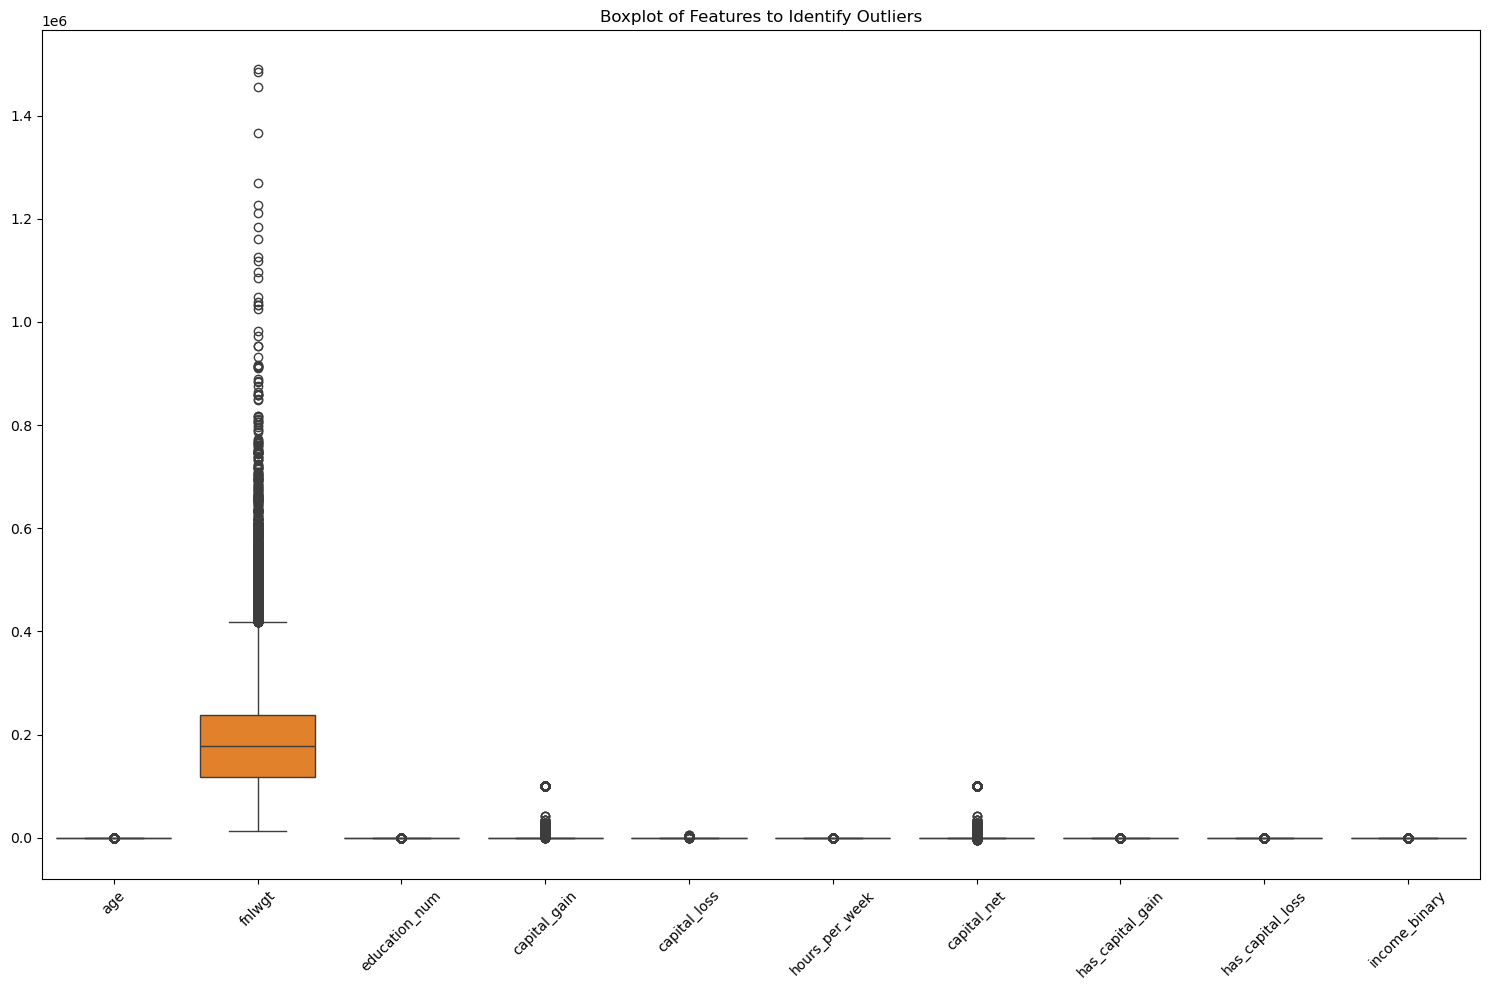

In [113]:
#boxplots to detect outliers
plt.figure(figsize=(15, 10))
sns.boxplot(data=df_final)
plt.title("Boxplot of Features to Identify Outliers")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [125]:
def train_and_evaluate(df, target_col='income_binary'):
    X = df.drop(columns=[target_col, 'source'], errors='ignore')
    X = pd.get_dummies(X, drop_first=True)
    y = df[target_col]

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.3, random_state=42
    )

    lr = LogisticRegression(max_iter=1000)
    lr.fit(X_train, y_train)
    y_pred = lr.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    
    print("Classification Report:")
    print(classification_report(y_test, y_pred))
    return acc

In [121]:
df_cleaned = pd.read_csv("cleaned_data/adult_combined_cleaned.csv")
accuracy = train_and_evaluate(df_cleaned)
print(f"Accuracy: {accuracy:.4f}")

Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.93      0.90     11109
           1       0.73      0.54      0.62      3544

    accuracy                           0.84     14653
   macro avg       0.79      0.74      0.76     14653
weighted avg       0.83      0.84      0.83     14653

Accuracy: 0.8392


In [126]:
#70/30 split
X_train, X_test, y_train, y_test = train_test_split (X, y, test_size = 0.3, random_state = 42)

In [127]:
# Scale features (MinMaxScaler)
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)   # Fit and scale training data
X_test_scaled = scaler.transform(X_test)

In [128]:
#knn model
knn_70 = KNeighborsClassifier(n_neighbors=16)
knn_70.fit(X_train_scaled, y_train)

KNeighborsClassifier(n_neighbors=16)

In [134]:
y_pred_knn = knn_70.predict(X_test_scaled)

In [136]:
print("KNN Test Accuracy (70/30) k 16 :", accuracy_score(y_test, y_pred_knn))

KNN Test Accuracy (70/30) k 16 : 0.8334129529789122


In [129]:
#checking the dimensions
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

X_train shape: (34189, 96)
X_test shape: (14653, 96)


In [131]:
# Scale features (MinMaxScaler)
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)   # Fit and scale training data
X_test_scaled = scaler.transform(X_test)

In [139]:
#knn model k12
knn_70 = KNeighborsClassifier(n_neighbors=12)
knn_70.fit(X_train_scaled, y_train)

y_pred_knn = knn_70.predict(X_test_scaled)

print("KNN Test Accuracy (70/30) k 12 :", accuracy_score(y_test, y_pred_knn))

KNN Test Accuracy (70/30) k 12 : 0.832866989694943


In [ ]:
#Evaluate clean data
df_original = pd.read_csv("cleaned_data/adult_combined_cleaned.csv")
acc_original = train_and_evaluate(df_original, target_col='income_binary')
print(f"Original Dataset Accuracy: {acc_original:.4f}")

Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.93      0.90     11109
           1       0.73      0.54      0.62      3544

    accuracy                           0.84     14653
   macro avg       0.79      0.74      0.76     14653
weighted avg       0.83      0.84      0.83     14653

Original Dataset Accuracy: 0.8392


In [ ]:
#evaluate other datasets
results = []

for file in os.listdir('./anonymized_datasets'):
    if file.startswith('adult_k') and file.endswith('.csv'):
        k = int(file.split('_')[1][1:])  # Extract k value
        df = pd.read_csv(f'./anonymized_datasets/{file}')
        df_num = df.select_dtypes(include='number')  # Use only numeric columns
        acc = train_and_evaluate(df_num, target_col='income_binary')
        results.append((k, acc))

# Sort and print results
for k, acc in sorted(results):
    print(f"k={k} → Accuracy: {acc:.4f}")

Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.75      0.79       106
           1       0.69      0.77      0.73        75

    accuracy                           0.76       181
   macro avg       0.76      0.76      0.76       181
weighted avg       0.77      0.76      0.76       181

Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.94      0.88       662
           1       0.76      0.50      0.60       247

    accuracy                           0.82       909
   macro avg       0.80      0.72      0.74       909
weighted avg       0.81      0.82      0.81       909

Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.89      0.85       317
           1       0.63      0.47      0.54       121

    accuracy                           0.78       438
   macro avg       0.72      0.68      0.70       438
weigh

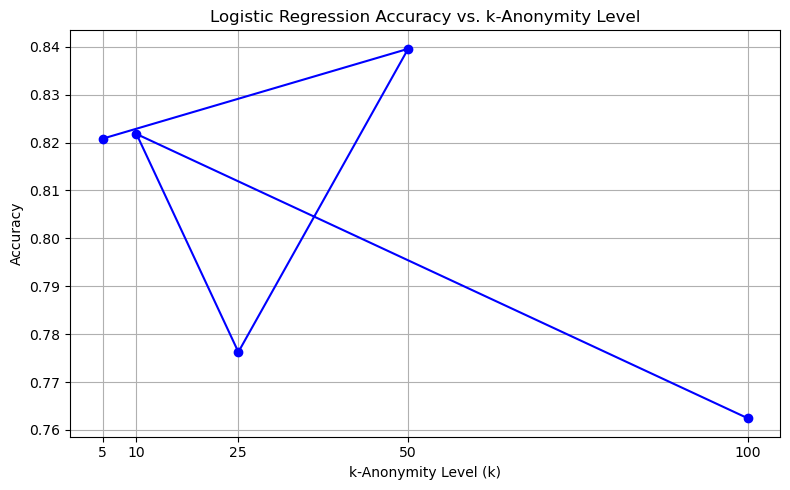

In [ ]:
#Extract k-values
k_values = [k for k, acc in results]
accuracies = [acc for k, acc in results]

#Plot
plt.figure(figsize=(8, 5))
plt.plot(k_values, accuracies, marker='o', linestyle='-', color='blue')
plt.title("Logistic Regression Accuracy vs. k-Anonymity Level")
plt.xlabel("k-Anonymity Level (k)")
plt.ylabel("Accuracy")
plt.grid(True)
plt.xticks(k_values)  # Ensure k-values appear on the x-axis
plt.tight_layout()
plt.show()